In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
DATA_PATH = "../data/raw/airbnb.csv"

df = pd.read_csv(DATA_PATH)

#Select the categorical columns

In [5]:
cols = [
    "price",
    "room type",
    "neighbourhood group",
    "lat",
    "long",
    "reviews per month",
    "availability 365"
]

df = df[cols].dropna()

#Create the demand Score

In [6]:
df["demand_score"] = df["reviews per month"] / (df["availability 365"] + 1)

#Price by Room Type

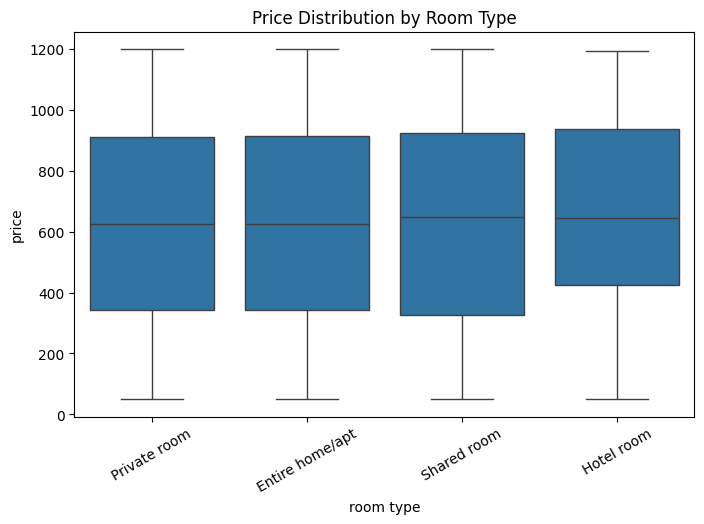

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="room type", y="price", data=df)
plt.title("Price Distribution by Room Type")
plt.xticks(rotation=30)
plt.show()

#Demand by Room Type

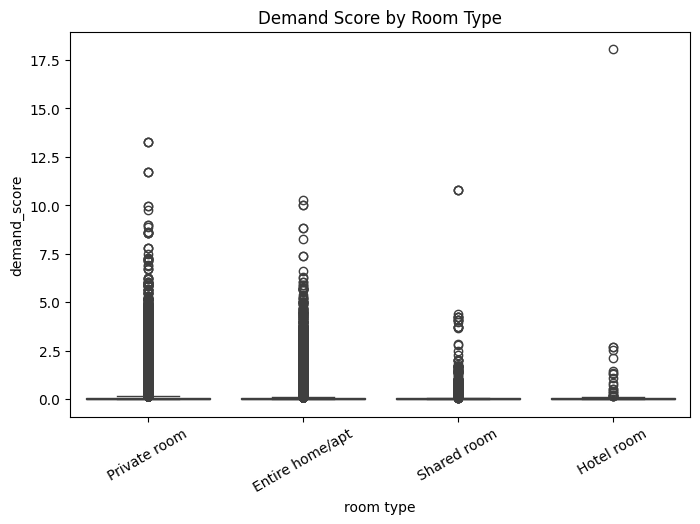

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="room type", y="demand_score", data=df)
plt.title("Demand Score by Room Type")
plt.xticks(rotation=30)
plt.show()

In [9]:
OUTPUT_DIR = "../artifacts/reports/eda/categorical_analysis/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.figure(figsize=(10, 6))
sns.boxplot(x="room type", y="price", data=df)
plt.title("Room Type Price Impact")
plt.savefig(OUTPUT_DIR + "room_type_impact.png")
plt.close()

#Location Analysis

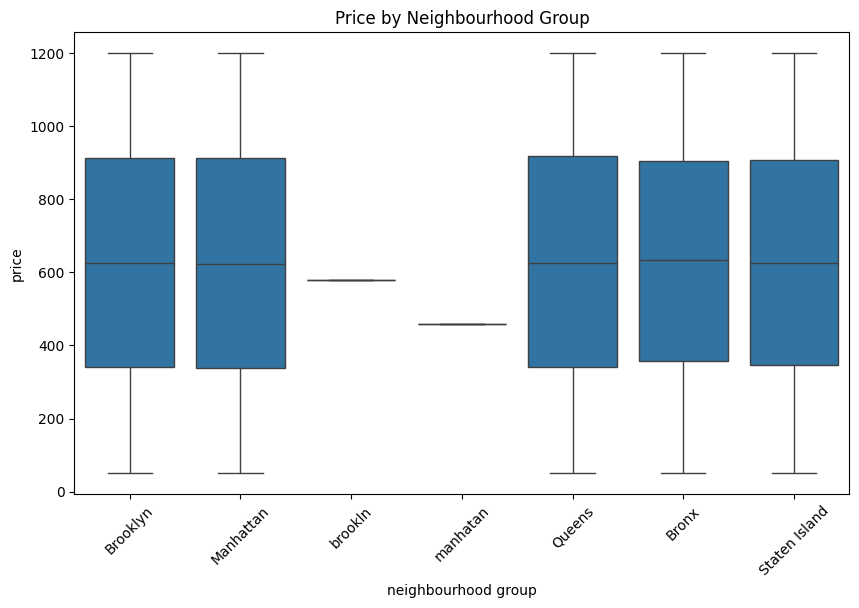

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="neighbourhood group", y="price", data=df)
plt.title("Price by Neighbourhood Group")
plt.xticks(rotation=45)
plt.show()

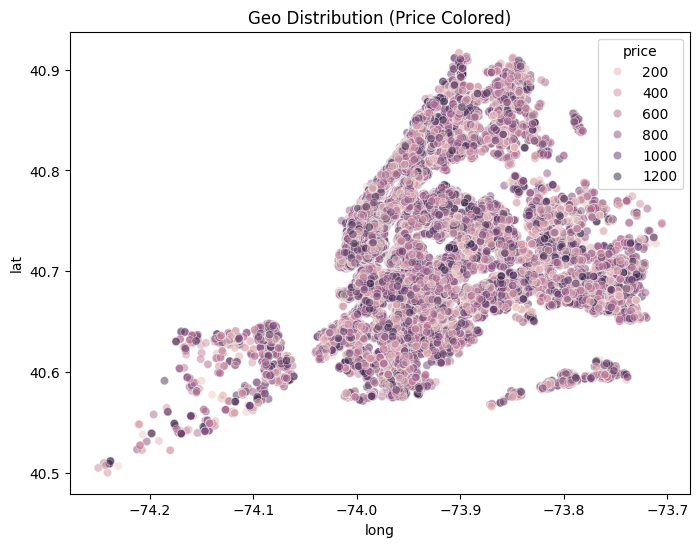

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df["long"],
    y=df["lat"],
    hue=df["price"],
    alpha=0.5
)
plt.title("Geo Distribution (Price Colored)")
plt.show()

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df["long"],
    y=df["lat"],
    hue=df["price"],
    alpha=0.5
)
plt.title("Location Price Distribution")

plt.savefig(OUTPUT_DIR + "neighbourhood_analysis.png")
plt.close()